<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks

Transformers also work pretty well with Image data though (you should probably revisit these topics in your other course).

Usually in the shape [batch_size, width, height, color_channels] or sometimes the color channels are first, then width and height.

- [32, 224, 224, 3] Here 32 is a common batch size, and 224*224 is also a common image size. 3 is also a common color channel, like RGB.

We're going to be building CNNs specifically in this course.

We will be working on a problem with low resolution and many classes, and hopefully despite the low resolution, our model works.

* 2 formats of formating the Dataset
- (NHWC) - examples, height, width, channels
- (NCHW) - examples, channels, height, width.

## What is a Convolutional Neural Network (CNN) ?



In [ ]:
import torch
from torch import nn

class CNN_Model(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int)
    super().__init__()
    self.cnn_layers = nn.Sequential(
        nn.Conv2d(
            in_channels = input_shape,
            out_channels = hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units * 32 * 32,
            out_features=output_shape
        )
    )

  def forward(self, x : torch.Tensor):
    x = self.cnn_layers(x)
    x = self.classifier(x)
    return x

cnn_models = CNN_Model(
    input_shape = 3,
    hidden_units=10,
    output_shape=3
)

## INPUTs and OUTPUTs

[[0.31, 0.62, 0.44],
[0.92, 0.38, 0.65],
[0.12, 0.78, 0.07]]

Comes out as

  Sushi, meat, or pizza
[[0.97, 0.00, 0.03],
[0.81, 0.14, 0.05],
[0.03, 0.07, 0.90]
...]

(My guess is there are multiple rows in the output because each represents one example, and the predictive probabilities. The input is for just one image though)

Transformers also perform very well with image data.

PyTorch defaults to colour channels first. This is important because you might get errors otherwise since your calculations won't quite fit.

- Libraries for Getting data ready and into Tensors
`torchvision.transforms`
`torch.utils.data.Dataset`
`torch.utils.data.DataLoader`

- Pretrained models
`torch.nn`
`torch.nn.Module`
`torchvision.models`

- Optimizer
`torch.optim`

- Metrics
`torchmetrics`

- Improve through experimentation
`torch.utils.tensorboard`

- Saving and reloading a trained model
`torch.save`
`torch.load`

# Starting computer Vision

## 0. Computer Vision Libraries in PyTorch

* `torchvision` is the main one for vision stuff

Looking at the Docs
  - torchaudio
    - For audio problems
  - torchtext
    - For text
  - torchvision
  - torchrec
    - For recommendation systems
  - torchdata
    - For dealing w/different data pipelines
  - torchserve
    - For serving PyTorch models
  - pytorch on Accelerated Linear Algebra (XLA) Devices

* `torchvision.datasets` - get datasets and data loading functions for computer vision
* `torchvision.models` - get pretrained computer vision models, that you can leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for use with an ML Model
* `torch.utils.data.Dataset` - Base dataset class for PyTorch
* `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset

In [ ]:
!pip uninstall sympy -y
!pip install sympy --upgrade --force-reinstall

Found existing installation: sympy 1.13.1
Uninstalling sympy-1.13.1:
  Successfully uninstalled sympy-1.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 37.3 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-c

In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
# ToTensor transforms into a Tensor
# pytorch.org/vision/stable/transforms.html
# Converting a PIL Image or numpy.ndarray into tensors.

# Import matplotlib for visualization
import matplotlib.pyplot as plt

In [ ]:
# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


# START - DATASET

Fashion MNIST.
A take on the original MNIST Database. Sample images from the MNIST dataset.

It's of grayscale images of pieces of clothing. We'll try to convert them into numbers, and then train a CNN to recognize items of clothing.

In PyTorch's documentation, there are example datasets you can see that we can try out.

In [ ]:
# MNIST Dataset
# Grayscale images of digits

# We must download the data and create a Data Loader.

# from torchvision import datasets //This allows us to call `datasets` directly
train_data = datasets.FashionMNIST(
    root = "data",
    train=True, # Do we want the Training Dataset?
    download=True,
    transform=torchvision.transforms.ToTensor(), #What do we need to do with our images to use them? Transform them into tensors.
    target_transform=None # How do we want to transform the labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [ ]:
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image class: '{class_names[label]}' (index {label})")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image class: 'Ankle boot' (index 9)


## 1.2 Visualizing our Data


Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image class: 'Ankle boot' (index 9)


Text(0.5, 1.0, '9')

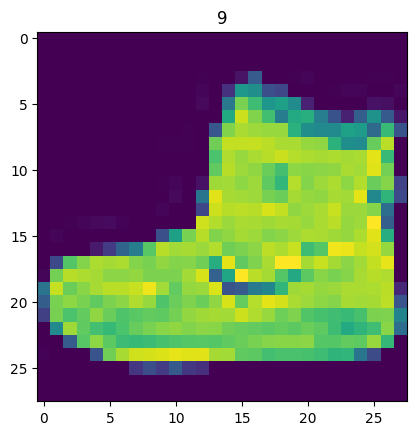

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image class: '{class_names[label]}' (index {label})")


plt.imshow(image.squeeze()) # `imshow` expects either just W*H or the color channels at the end
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

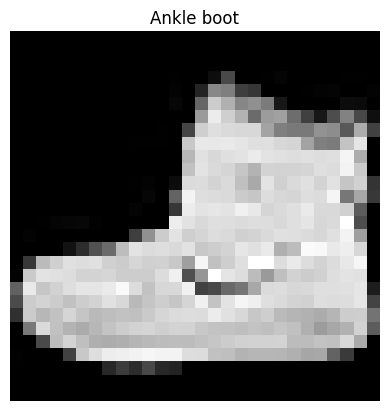

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

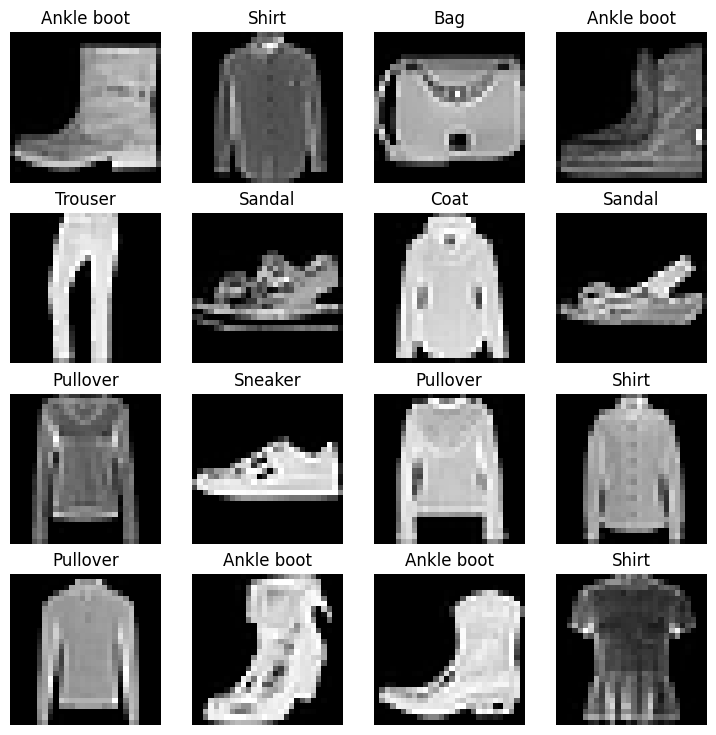

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

Do you think we need a model with non-linearity, or will a model with just straight lines suffice (just linear lines)?

Also, notice that the items are sometimes confusing, in the sense that if we humans can struggle identifying an item, so too may the model struggle with those cases.


In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

Look above, we can see detailed information about the PyTorch Datasets we got.

# 2. Prepare Dataloader

Right now, our data is in the form of PyTorch datasets

`DataLoader` turns our dataset into a Python iterable. More specifically, we want to turn our data into batches (or `mini-batches`)

Why would we do this?
  1. More computationally efficient for your computing hardware, since it may not be able to look (store in memory) at 60k images in one hit. We break it down to batches of some 2^n, for example, 32.
  2. It gives our NN more chances to update its gradients per epoch. Mini-Batch GD is a good balance between big steps (Batch GD), and super wobbly steps (Stochastic GD).


Note: 60k images is small, we can have datasets with millions of images.

In [ ]:
# DATA LOADER
# Turns our dataset into a Python iterable
from torch.utils.data import DataLoader

# Setup BATCH SIZE Hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (Batches)

train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)
# It's generally better to keep the Test dataset in the same order, no need to shuffle
# That's because you're model won't see it until test time

In [ ]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7feb619a1e10>,
 <torch.utils.data.dataloader.DataLoader at 0x7feb61dd1b50>)

In [ ]:
# Let's check it out
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of TrainDL: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of TestDL: {len(test_dataloader)} batches of {BATCH_SIZE}")
# Maybe the last batch doesn't have 32 samples, because the total doesn't divide perfectly.

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7feb619a1e10>, <torch.utils.data.dataloader.DataLoader object at 0x7feb61dd1b50>)
Length of TrainDL: 1875 batches of 32
Length of TestDL: 313 batches of 32


In [ ]:
train_dataloader.batch_size
#pin_memory is for loading data faster
# drop_last is to drop a batch, one reason is you have few examples in there
# and so on... there are many features.

32

In [ ]:
len(train_data) % BATCH_SIZE

0

In [ ]:
# For the test dataset you can see that there will be a batch with 16 examples.
len(test_data) % BATCH_SIZE

16

In [ ]:
# Let's check out what's inside the Training DataLoader
train_features_batch, train_labels_batch = next(iter(train_dataloader))

In [ ]:
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
# Show a sample
torch.manual_seed(42)

Image size: torch.Size([1, 28, 28])
Label: Shirt, label shape: torch.Size([])


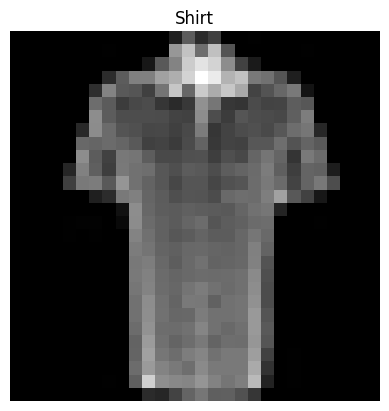

In [ ]:
random_idx = torch.randint(
    0,
    len(train_features_batch),
    size=[1]
).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {class_names[label]}, label shape: {label.shape}")

# 3. Model 0: Build a Baseline Model

A baseline model is a simple model you will try and improve upon with subsequent models/experiments

In other words: start simply and add complexity when necessary

In [ ]:
# Create a `flatten` layer
#   It flattens a Contiguous Range of Dims into a Tensor. For use with nn.Sequential

flatten_model = nn.Flatten() #All nn Modules can be used as a model on their own.

# Get a single sample
x = train_features_batch[0]
x.shape

# Flatten the sample
output = flatten_model(x) #Performs the Forward Pass

# Print
print(f"Shape before: {x.shape} | Shape after: {output.shape} (28*28={28*28})")
print(f"It went from [C, H, W] to [1, C*H*W]")

# Tesla converts cameras into 3-D Vector Space.

Shape before: torch.Size([1, 28, 28]) | Shape after: torch.Size([1, 784]) (28*28=784)
It went from [C, H, W] to [1, C*H*W]


In [ ]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(
      self,
      input_shape : int,
      hidden_units : int,
      output_shape : int
  ):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Flatten(), #This `flatten` layer has NO learnable parameters.
      nn.Linear(
          in_features = input_shape,
          out_features = hidden_units
      ),
      nn.Linear(
          in_features = hidden_units,
          out_features= output_shape
      )
    )

  def forward(self, x):
    return self.layer_stack(x)

Will our model work as is? (most likely it won't)

In [ ]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names) #One for every class
).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

## Dummy Forward Pass

In [ ]:
dummy_x = torch.rand([1, 1, 28, 28]) # One example of shape [1, 28, 28]
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

If we get rid of `Flatten` then the shapes suddenly won't match, and we get an error.

## 3.1 Setup `Optimizer` and `Evaluation Metrics`

* Loss Function

For multi-class data, our Loss Fn will be `nn.CrossEntropyLoss()`

* Optimizer

We may stick with SGD, the standard one.

* Evaluation Metric

A Classification problem, let's use Accuracy as our Eval Metric.

You can find out about these in the `Torchmetrics` website

In [ ]:
def accuracy_fn(y_true, y_pred):
  """Calculates accuracy between truth labels and predictions

  Args:
    y_true (torch.Tensor): Truth labels
    y_pred (torch.Tensor): Predictions to be compared

  Returns:
    [torch.float]: Accuracy value btw y_true and y_pred, e.g. 78.45

  """
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download...")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
# Importing our accuracy function
from helper_functions import accuracy_fn

In [ ]:
# Setup LOSS FUNCTION and OPTIMIZER

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr = 0.05 #He set it to 0.1 #Learning Rate
)

## 3.2 Creating a function to time our experiments

ML is very experimental. 2 of the main things you'll often want to track

1. Model performance (Loss, Accuracy, etc.)
2. How fast it runs.

Ideally you have a precise, fast model. But there's often a tradeoff, because to get a better model, more computations are in order.

In [ ]:
# `timeit` in Python.
from timeit import default_timer as timer

def print_train_time(
    start: float,
    end: float,
    device: torch.device = None
):
  """Prints difference between start and end time.
  """
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f}")
  return total_time

In [ ]:
start_time = timer()
end_time = timer()
print_train_time(
    start=start_time,
    end=end_time,
    device="cpu"
)

Train time on cpu: 0.000


2.623899999321111e-05

## 3.3 Creating a Training Loop and Training a Model on batches of data.

The optimizer now updates once per mini-batch, instead of once per each Training Set pass (epoch)

That means you update your parameter multiple times per epoch now.

1. Loop through epochs
2. Loop through Training Batches, perform training steps, calculate the train loss *per batch*
3. Loop through Testing Batches, perform testing steps, calculate the test loss *per batch*
4. Print out what's happening
5. Time it all (for fun)

In [ ]:
# Import `tqdm` to get a progress bar
from tqdm.auto import tqdm #Auto recognizes our environment and gives us a progress bar for it

# Seed and timer start
torch.manual_seed(42)
train_cpu_start = timer()

# Set # of epochs
epochs = 3 #Start with something like this which runs fast so you can detect if something went wrong

# TRAINING AND TEST LOOP
for epoch in tqdm(range(epochs)): #tqdm is here
  print(f"Epoch: {epoch} \n-----")

  #Training
  train_loss = 0

  # Loop through our training batch
  for index, (X, y) in enumerate(train_dataloader): # The index is the batch number, X is the image, y is the label
    # Put model in training mode
    model_0.train()
    # 1. Forward Pass
    y_pred = model_0(X)

    # 2. Calculate loss (per batch now)
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    if index % 400 == 0:
      print(f"Looked at {index * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Outside the batch loop, we want the average loss per batch
  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader) # I suppose len(train_dataloader) gives you the number of batches

  test_loss, test_acc = 0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 1. Forward pass
      y_test_pred = model_0(X_test)

      # 2. Calculate loss (accumulatively, since we want to know for the whole test dataset, not just a batch)
      test_loss += loss_fn(y_test_pred, y_test)

      # 3. Accuracy
      y_test_preds = y_test_pred.argmax(dim=1)
      test_acc += accuracy_fn(y_true=y_test, y_pred=y_test_preds)

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  #Right now it's printing per epoch
  print(f"\nTrainLoss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

train_cpu_end = timer()
device_str = str(next(model_0.parameters()).device )
total_train_time_model_0 = print_train_time(
    start= train_cpu_start,
    end = train_cpu_end,
    device=device_str
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

TrainLoss: 0.6205 | Test loss: 0.5041, Test Acc: 82.1486
Epoch: 1 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

TrainLoss: 0.4746 | Test loss: 0.4727, Test Acc: 83.5563
Epoch: 2 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

TrainLoss: 0.4502 | Test loss: 0.4679, Test Acc: 83.5064
Train time on cpu: 28.116


In [ ]:
str(next(model_0.parameters()).device)

'cpu'

# 4. Make predictions and get Model 0 results

In [ ]:
torch.manual_seed(42)
def eval_model(
  model: torch.nn.Module,
  data_loader: torch.utils.data.DataLoader,
  loss_fn: torch.nn.Module,
  accuracy_fn
):
  """Returns a dictionary containing the results of Model Predicting on data_loader
  """
  loss, acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:
      y_test_pred = model(X)
      y_test_pred_idxs = y_test_pred.argmax(dim=1)

      loss += loss_fn(y_test_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_test_pred_idxs)

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {
      "model_name": model.__class__.__name__,
      "model_loss": loss,
      "model_acc": acc
  }

In [ ]:
model_0_results = eval_model(
    model=model_0,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': tensor(0.4679),
 'model_acc': 83.50638977635782}

# 5. Set up Device-Agnostic Code for GPU.

In [ ]:
!nvidia-smi

Sun Jul 27 00:46:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

In [ ]:
torch.cuda.is_available()

True

In [ ]:
#Device-agnostic code setup.
device = "cuda" if torch.cuda.is_available() else "cpu"

# 6. Creating a Non-Linear Model

In [ ]:
from torch import nn

class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU() #Curious he ended it with an Activation
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
from torch import nn
class FashionMNISTModelVP(nn.Module):
  def __init__(self,
      input_shape : int,
      hidden_units : int,
      output_shape : int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
next(model_0.parameters()).device

device(type='cpu')

In [ ]:
model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [ ]:
next(model_1.parameters()).device

device(type='cuda', index=0)

## 6.1 Setup Loss, Optimizer, and Evaluation Metrics

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss() #We are keeping this the same to be able to see if Non-Linearity makes a difference
optimizer = torch.optim.SGD(
    params = model_1.parameters(),
    lr = 0.1
)

### 6.1.1 Turning our Training and Test Steps into a function

In [ ]:
type(train_dataloader)

torch.utils.data.dataloader.DataLoader

In [ ]:
def train_step(
    model : torch.nn.Module,
    train_dataloader : torch.utils.data.DataLoader, #: torch.utils.data.dataloader.DataLoader,
    optimizer : torch.optim.Optimizer,
    loss_fn : torch.nn.Module,
    device : torch.device = device,
    accuracy_fn=None
):
  #Training
  train_loss = 0
  train_acc = 0
  model.train()

  # Loop through our training batch
  for index, (X, y) in enumerate(train_dataloader): # The index is the batch number, X is the image, y is the label
    # Put data in device
    X, y = X.to(device), y.to(device)

    # 1. Forward Pass
    y_pred = model(X)

    # 2.1 Calculate Accuracy
    if accuracy_fn is not None:
      y_preds_argmax = y_pred.argmax(dim=1)
      train_acc += accuracy_fn(y_true=y, y_pred=y_preds_argmax)


    # 2.2 Calculate loss (per batch now)
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    if index % 400 == 0:
      print(f"Looked at {index * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Outside the batch loop, we want the average loss per batch
  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader) # I suppose len(train_dataloader) gives you the number of batches
  train_acc /= len(train_dataloader)
  print(f"IF TL {train_loss:.5f} | TA: {train_acc:.2f}")
  return train_loss, train_acc

In [ ]:
def test_step(
    model : torch.nn.Module,
    test_dataloader : torch.utils.data.DataLoader,
    optimizer : torch.optim.Optimizer,
    loss_fn : torch.nn.Module,
    device : torch.device = device,
    accuracy_fn=None
):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 0. Move tensors to device
      X_test, y_test = X_test.to(device), y_test.to(device)

      # 1. Forward pass
      y_test_pred = model(X_test)

      # 2. Calculate loss (accumulatively, since we want to know for the whole test dataset, not just a batch)
      test_loss += loss_fn(y_test_pred, y_test)

      # 3. Accuracy
      if (accuracy_fn is not None):
        y_test_argmax = y_test_pred.argmax(dim=1)
        test_acc += accuracy_fn(y_true=y_test, y_pred=y_test_argmax)

    if accuracy_fn is None:
      test_acc = 0.0

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    print(f"IF TL {test_loss:.5f} | TA: {test_acc:.2f}")
    return test_loss, test_acc

In [ ]:
# Import `tqdm` to get a progress bar
from tqdm.auto import tqdm #Auto recognizes our environment and gives us a progress bar for it

# Seed and timer start
torch.manual_seed(42)
train_gpu_start = timer()

# Set # of epochs
epochs = 3 #Start with something like this which runs fast so you can detect if something went wrong

# TRAINING AND TEST LOOP
for epoch in tqdm(range(epochs)): #tqdm is here
  print(f"Epoch: {epoch} \n-----")
  train_loss, train_acc = train_step(
      model=model_1,
      train_dataloader=train_dataloader,
      optimizer=optimizer,
      device = device,
      loss_fn = loss_fn,
      accuracy_fn=accuracy_fn
  )

  test_loss, test_acc = test_step(
      model=model_1,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      device = device,
      accuracy_fn=accuracy_fn
  )

  #Right now it's printing per epoch
  print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} \nTest loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

train_gpu_end = timer()
device_str = str(next(model_1.parameters()).device )
total_train_time_model_1 = print_train_time(
    start= train_gpu_start,
    end = train_gpu_end,
    device=device_str
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
IF TL 2.31424 | TA: 13.95
IF TL 2.31340 | TA: 13.90

Train Loss: 2.3142, Train Acc: 13.9467 
Test loss: 2.3134, Test Acc: 13.8978
Epoch: 1 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
IF TL 2.31424 | TA: 13.95
IF TL 2.31340 | TA: 13.90

Train Loss: 2.3142, Train Acc: 13.9467 
Test loss: 2.3134, Test Acc: 13.8978
Epoch: 2 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
IF TL 2.31424 | TA: 13.95
IF TL 2.31340 | TA: 13.90

Train Loss: 2.3142, Train Acc: 13.9467 
Test loss: 2.3134, Test Acc: 13.8978
Train time on cuda:0: 32.577


In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': tensor(0.4679),
 'model_acc': 83.50638977635782}

In [ ]:
torch.manual_seed(42)
def eval_model(
  model: torch.nn.Module,
  data_loader: torch.utils.data.DataLoader,
  loss_fn: torch.nn.Module,
  accuracy_fn,
  device : torch.device = device
):
  """Returns a dictionary containing the results of Model Predicting on data_loader
  """
  loss, acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      y_test_pred = model(X)
      y_test_pred_idxs = y_test_pred.argmax(dim=1)

      loss += loss_fn(y_test_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_test_pred_idxs)

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {
      "model_name": model.__class__.__name__,
      "model_loss": loss,
      "model_acc": acc
  }

model_1_results = eval_model(
    model=model_1,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': tensor(2.3134, device='cuda:0'),
 'model_acc': 13.89776357827476}

# Model 2: Building a Convolutional Neural Network (CNN)

Good for processing images, even text if words are transformed into vectors.

Find patterns in visual data.

These usually have
- Input Layer
  - Takes in target images and preprocesses them for further layers
- Convolution Layers
  - Extracts/learns the most important features from target images
- Hidden Activations / Non-linear Activations
  - Add non-linearity to Learned Features (non-straight lines)
- Pooling Layer(s)
  - Reduces the dimensionality of learned image features
- Output layer / Linear Layer
  - Takes learned features and outputs them in shape of the target labels
- Output Activation
  - Converts output logits to prediction probabilities.

See [this website](https://poloclub.github.io/cnn-explainer/)

In [ ]:
import torch
from torch import nn

In [ ]:
# Create a Convolutional Neural Network

class FashionMNISTModelV2(nn.Module):
  """
    Model architecture that replicates the TinyVGG
    model from the CNN Explainer website
  """
  def __init__(self, input_shape: int, hidden_units : int, output_shape : int):
    super().__init__()
    # Convolutional Block 1 - Feature Extractor
    self.conv_block_1 = nn.Sequential(
        # Create a conv layer (Convolution 2D)
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    # Convolutional Block 2 - Feature Extractor
    self.conv_block_2 = nn.Sequential(
        # Create a conv layer (Convolution 2D)
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    # Classifier Layer, takes the extracted features to classify
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units*7*7,
            out_features=output_shape
        )
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(f"Shape after block 1: {x.shape}")
    x = self.conv_block_2(x)
    #print(f"Shape after block 2: {x.shape}")
    x = self.classifier(x)
    #print(f"Shape after classifier: {x.shape}")
    return x

# Values we can set ourselves in NNs are called hyperparameters

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(
    input_shape=1, #We have only one color channel, while the VGG examples handles 3-channel images
    hidden_units=10, #As seen in Tiny VGG
    output_shape=len(class_names)
).to(device)

You'll get an error here the first time saying:

    Initializing zero-element tensors is a no-op
    warnings.warn("Initializing zero-element tensors is a no-op")

This is because we defined one of the layers as

    in_features=hidden_units*0

It notices that the size is effectively 0. But we're doing this to probably find out the shape we are expecting, so that we can put it in correctly there.

## 7.1 Stepping through `nn.Conv2d`

In PyTorch's documentation you can see what's happening for yourself. Also [CNN Explainer](https://poloclub.github.io/cnn-explainer/) has a pretty neat visualization of Stride, Kernel, Padding, and Input Size

In [ ]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

In [ ]:
print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])


In [ ]:
print(f"Image: \n{image}")

Image: 
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157,

In [ ]:
# Let's also see the model
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

In [ ]:
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=0, out_features=10, bias=True)
  )
)

In [ ]:
torch.manual_seed(42)
# Create a single Conv2D Layer
conv_layer = nn.Conv2d(in_channels=3, #Because we have 3 color channels.
                       out_channels=10,
                       kernel_size=(3,3), #You can also specify it this way.
                       stride=1,
                       padding=0
                       )

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
conv_output = conv_layer(test_image)

In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
conv_output.shape

torch.Size([10, 62, 62])

So it transformed from [3, 64, 64] to [10, 62, 62]

Now let's try changing values

In [ ]:
conv_layer = nn.Conv2d(in_channels=3, #Because we have 3 color channels.
                       out_channels=10,
                       kernel_size=(3,3), #You can also specify it this way.
                       stride=2,
                       padding=1
                       )
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 32, 32])

## 7.2 Stepping through `nn.MaxPool2d()`

You can find out about it through the documentation.

In [ ]:
#Print out original image shape without unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image w/unsqueezed dimension: {test_image.unsqueeze(0).shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image w/unsqueezed dimension: torch.Size([1, 3, 64, 64])


In [ ]:
#Create a model out of just a MaxPool, since that's how nn.Modules work
max_pool_layer = nn.MaxPool2d(kernel_size=2)

test_image_through_conv = conv_layer(test_image)
print(f"Shape after conv_layer: {test_image_through_conv.shape}")

test_image_through_conv_and_mp = max_pool_layer(test_image_through_conv)
print(f"Shape after Conv and MaxPool2d: {test_image_through_conv_and_mp.shape}")

Shape after conv_layer: torch.Size([10, 32, 32])
Shape after Conv and MaxPool2d: torch.Size([10, 16, 16])


In [ ]:
torch.manual_seed(42)

#Create a random tensor with a similar number of dimensions
random_tensor = torch.randn(size=(1, 1, 2, 2))
random_tensor

tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

In [ ]:
# Creating another maxPool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

max_pool_tensor = max_pool_layer(random_tensor)
print(f"Shape: {max_pool_tensor.shape}")
print(f"\nMax Pool Tensor:\n {max_pool_tensor}")

Shape: torch.Size([1, 1, 1, 1])

Max Pool Tensor:
 tensor([[[[0.3367]]]])


## 7.3 Using our Convolutional Model

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
model_2(image.unsqueeze(0).to(device)) #I was missing the `unsqueeze` before to add a dimension that implies it's 1 example

tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]], device='cuda:0', grad_fn=<AddmmBackward0>)

We need to correct our shape, now we know that what it receives
is of shape (10, 7, 7)

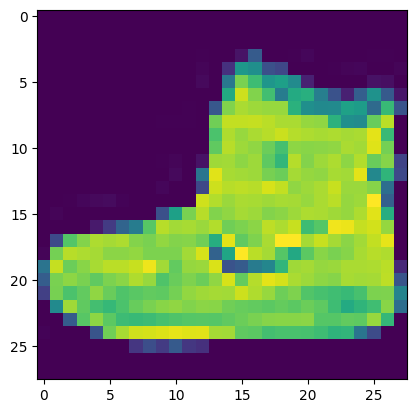

In [ ]:
plt.imshow(image.squeeze())

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr=0.1
)

## 7.4 Training and Testing `model_2` using our Training and Test functions

In [ ]:
# `timeit` in Python.
from timeit import default_timer as timer

def print_train_time(
    start: float,
    end: float,
    device: torch.device = None
):
  """Prints difference between start and end time.
  """
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f}")
  return total_time

In [ ]:
# Import `tqdm` to get a progress bar
from tqdm.auto import tqdm #Auto recognizes our environment and gives us a progress bar for it

# Seed and timer start
torch.manual_seed(42)
train_time_start = timer()

# Set # of epochs
epochs = 3 #Start with something like this which runs fast so you can detect if something went wrong

# TRAINING AND TEST LOOP
for epoch in tqdm(range(epochs)): #tqdm is here
  print(f"Epoch: {epoch} \n-----")
  train_loss, train_acc = train_step(
      model=model_2,
      train_dataloader=train_dataloader,
      optimizer=optimizer,
      device = device,
      loss_fn = loss_fn,
      accuracy_fn=accuracy_fn
  )

  test_loss, test_acc = test_step(
      model=model_2,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      device = device,
      accuracy_fn=accuracy_fn
  )

  #Right now it's printing per epoch
  print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} \nTest loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

train_time_end = timer()
device_str = str(next(model_2.parameters()).device )
total_train_time_model_2 = print_train_time(
    start= train_time_start,
    end = train_time_end,
    device=device_str
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
IF TL 0.30226 | TA: 89.04
IF TL 0.30607 | TA: 88.92

Train Loss: 0.3023, Train Acc: 89.0400 
Test loss: 0.3061, Test Acc: 88.9177
Epoch: 1 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
IF TL 0.28796 | TA: 89.48
IF TL 0.31465 | TA: 88.55

Train Loss: 0.2880, Train Acc: 89.4783 
Test loss: 0.3147, Test Acc: 88.5483
Epoch: 2 
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
IF TL 0.27791 | TA: 89.98
IF TL 0.31472 | TA: 88.57

Train Loss: 0.2779, Train Acc: 89.9800 
Test loss: 0.3147, Test Acc: 88.5683
Train time on cuda:0: 37.088


In [ ]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': tensor(0.3187, device='cuda:0'),
 'model_acc': 88.57827476038338}

# 8. Comparing model results and training time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame(
    [model_0_results,
     model_1_results,
     model_2_results]
)

In [ ]:
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,tensor(0.4679),83.506390
1,FashionMNISTModelV1,"tensor(2.3134, device='cuda:0')",13.897764
2,FashionMNISTModelV2,"tensor(0.3187, device='cuda:0')",88.578275


In [ ]:
# Add training time to results comparison
#   Performance-Speed Trade-off
compare_results["training_time"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2
]

In [ ]:
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,tensor(0.4679),83.506390,28.116160
1,FashionMNISTModelV1,"tensor(2.3134, device='cuda:0')",13.897764,32.576731
2,FashionMNISTModelV2,"tensor(0.3187, device='cuda:0')",88.578275,37.088474


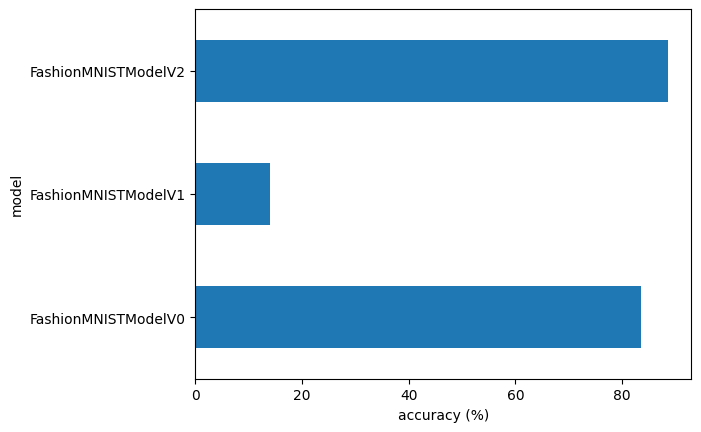

In [ ]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh") #`barh` will make it so it prints horizontally
plt.xlabel("accuracy (%)")
plt.ylabel("model"); #This `;` stops it from printing the little line of text you'll see.

# 9. Make and evaluate random predictiosn with best model

In [ ]:
def make_predictions(model : torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
      for sample in data:
        # Prepare the sample (add a batch dimension and pass to target device)
        sample = torch.unsqueeze(sample, dim=0).to(device) #So you are saying that it's a batch of 1 sample

        # Forward pass
        pred_logit = model(sample)

        # Get prediction probability (logit -> Pred Prob)
        pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

        # Get pred_prob off the GPU for further calculations
        pred_probs.append(pred_prob.cpu())

  #Stack pred_probs to turn listo into a tensor
  return torch.stack(pred_probs)

In [ ]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [ ]:
img, label = test_data[0][:10]
img.shape, label

(torch.Size([1, 28, 28]), 9)

In [ ]:
import random
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

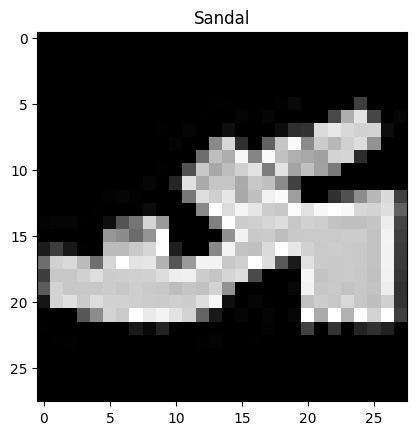

In [ ]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [ ]:
pred_probs = make_predictions(
    model=model_2,
    data=test_samples
)

In [ ]:
pred_probs[:2]

tensor([[3.6015e-08, 4.9794e-09, 2.8804e-08, 3.3237e-07, 1.1041e-07, 9.9998e-01,
         1.8439e-07, 6.8102e-07, 3.6425e-06, 1.0420e-05],
        [1.1382e-01, 7.4060e-01, 6.0073e-03, 4.3517e-02, 4.5918e-03, 4.8964e-04,
         8.9378e-02, 5.0688e-04, 1.0078e-03, 7.8058e-05]])

In [ ]:
pred_labels = torch.argmax(pred_probs, dim=1)
pred_labels, test_labels

(tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]), [5, 1, 7, 4, 3, 0, 4, 7, 1])

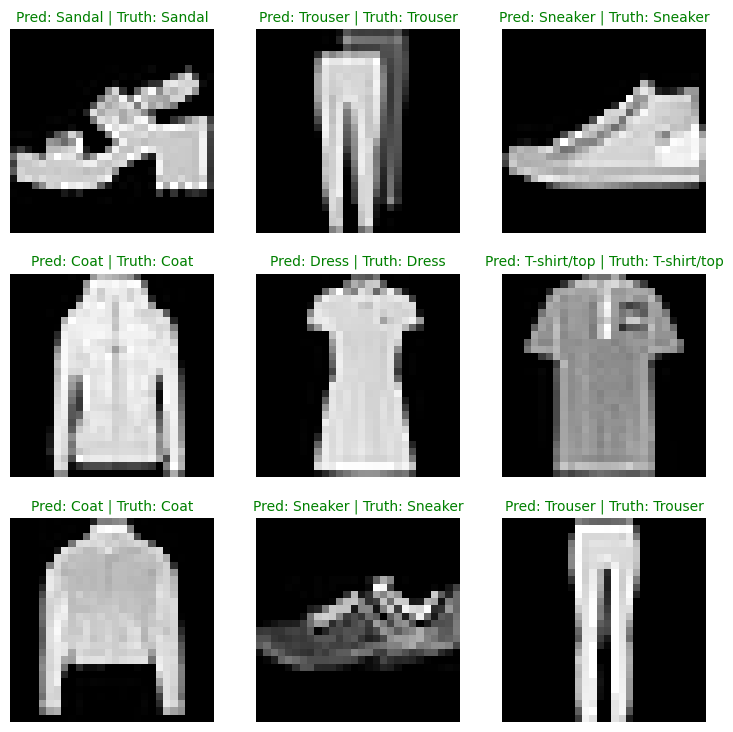

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9)) # 3*3 plot
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows, ncols, i+1) #This last parameter is the index it's going to be on.

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction (in text form, e.g. "Shirt")
  pred_label = class_names[pred_labels[i]]

  # Get the truth label (in text form)
  truth_label = class_names[test_labels[i]] #We'll check if these match

  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g") #Green if same
  else:
    plt.title(title_text, fontsize=10, c="r") #Red if different
  plt.axis(False) #It needs to run within the loop so that it turns it off for every subplot.

# 10. Making a Confusion Matrix for further prediction evaluation

1. Make predictions with our trained model on the test dataset
2. Make a confusion matrix with `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

`Mlxtend` is a library from Sebastian Raschka, who wrote ML with PyTorch and Scikit-Learn


In [ ]:
# Import tqdm.auto
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(
      test_dataloader,
      desc="Making predictions..."
  ):
    # Send the data and targets to target device
    X, y = X.to(device), y.to(device)

    # Do forward pass
    y_logit = model_2(X)

    # Pred probs
    y_pred_probs = torch.softmax(y_logit.squeeze(), dim=0)

    # Pred Labels
    y_labels = torch.argmax(y_pred_probs, dim=1)

    # Put prediction on CPU for evaluation
    y_preds.append(y_labels.cpu())

#print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor[:10]

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
len(y_pred_tensor)

10000

In [ ]:
# See if required packages are installed, and if not, install them...
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1] >= 19, "MLXTend should be version 19 or higher")
except:
  print(f"Installing torchmetrics, mlxtend")
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

Installing torchmetrics, mlxtend
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.0 MB/s eta 0:00:00
mlxtend 

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

In [ ]:
confmat_tensor

tensor([[703,   5,  29,  55,  11,   0, 189,   0,   8,   0],
        [ 13, 880,   5,  79,  11,   0,   7,   0,   4,   1],
        [ 11,   1, 751,  14, 108,   0, 107,   0,   8,   0],
        [ 32,  11,  21, 850,  35,   0,  43,   0,   6,   2],
        [ 10,   4,  87,  54, 710,   0, 125,   0,  10,   0],
        [  9,   0,  15,  16,   1, 814,   8,  55,  61,  21],
        [ 95,   5,  87,  58,  81,   1, 660,   0,  13,   0],
        [  0,   2,   0,   0,   0,  29,   0, 906,   8,  55],
        [ 10,   4,  14,  17,  12,   8,  55,   8, 870,   2],
        [  0,   0,   1,   4,   0,  28,   7,  87,   9, 864]])

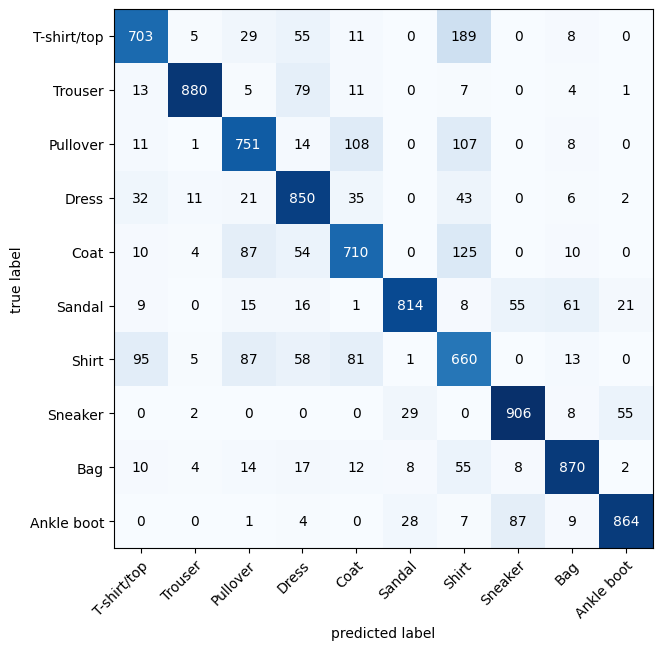

In [ ]:
# 3. Plot our confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), #matplotlib underneath, which likes working w/ NumPy
    class_names = class_names,
    figsize=(10, 7)
)

# 11. Save and Load our Model

In [ ]:
from pathlib import Path

# Create model directory Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

PosixPath('models/03_pytorch_computer_vision_model_2.pth')

In [ ]:
# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


## 11.1 Loading our saved parameters into a new model

In [ ]:
torch.manual_seed(42)

model_2_instance = FashionMNISTModelV2( #The arguments need to be the same
    input_shape = 1,  #We had one color channel, remember?
    hidden_units=10,
    output_shape=len(class_names)
)

# Loading parameters
model_2_instance.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# send model to target device
model_2_instance = model_2_instance.to(device)

In [ ]:
model_2_instance

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': tensor(0.3187, device='cuda:0'),
 'model_acc': 88.57827476038338}

In [ ]:
torch.manual_seed(42)

loaded_2_model_results = eval_model(
    model=model_2_instance,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
loaded_2_model_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': tensor(0.3147, device='cuda:0'),
 'model_acc': 88.56829073482429}

## Checking if model results are close

In [ ]:
torch.isclose(model_2_results["model_loss"].clone().detach(),
              loaded_2_model_results["model_loss"].clone().detach(),
              atol=1e-02)

tensor(True, device='cuda:0')

# 12. ChatGPT update for correct upload to Github

I found an issue with widget metadata that prevents my notebook from being correctly displayed in Github, so hopefully, here's a timely fix for it.

In [ ]:
import nbformat

notebook_path = '/content/drive/MyDrive/Colab Notebooks/03_pytorch_computer_vision.ipynb'  # Update as needed

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']
    print("Removed 'widgets' metadata.")
else:
    print("No 'widgets' metadata found.")

with open(notebook_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)
    print("Notebook cleaned and saved back to Drive.")
